# Module 1: Telco Customer Churn Prediction & Decision Modeling

Welcome to **Module 1**! In this practical lab, you will analyze customer churn for a telecommunications provider (`Telco-Customer-Churn.csv` — 7,043 customers, 21 columns).

### Business Brief:
A telecom company loses ~25% of its customers annually. Winning new customers costs 5x more than retaining existing ones. Your brief:
> *"Predict which customers are likely to churn, identify root causes, and determine the optimal intervention cutoff for retention calls."*

---

### Assignment Tasks Overview:
1. **Task 1**: Load `Telco-Customer-Churn.csv`, inspect schema, convert `TotalCharges` strings to float, and impute missing values.
2. **Task 2**: Exploratory Data Analysis — Analyze churn rates across contract types, tenure buckets, and monthly charges.
3. **Task 3**: Preprocessing & Feature Encoding — One-hot encode categorical features and scale numeric variables.
4. **Task 4**: Machine Learning Model Training — Train Logistic Regression and Random Forest classifiers.
5. **Task 5**: Business Decision Threshold Modeling — Evaluate Precision-Recall trade-offs to maximize retention campaign ROI.

In [21]:
# Task 1: Load Telco Churn Dataset & Handle Data Types
import pandas as pd
import numpy as np

# Load dataset (pre-mounted in workspace)
df = pd.read_csv('Telco-Customer-Churn.csv')

# Clean TotalCharges (spaces/blank strings -> NaN -> float)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode target variable
df['Churn_Numeric'] = (df['Churn'] == 'Yes').astype(int)

print(f"Dataset Shape: {df.shape}")
print("Churn Distribution:\n", df['Churn'].value_counts(normalize=True))
df.head()

Dataset Shape: (7043, 22)
Churn Distribution:
 No     0.73463
Yes    0.26537
Name: Churn, dtype: float64
--- Churn Rate by Contract Type ---
                count Churn_Rate
Contract                        
Month-to-month   3875     42.71%
One year         1473     11.27%
Two year         1695      2.83%

--- Churn Rate by Tenure Group ---
TenureGroup
0-1 yr     47.68%
1-2 yrs    28.71%
2-4 yrs    20.39%
4+ yrs      9.51%
Name: Churn_Numeric, dtype: object



<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>customerID</th>
      <th>gender</th>
      <th>SeniorCitizen</th>
      <th>Partner</th>
      <th>Dependents</th>
      <th>tenure</th>
      <th>PhoneService</th>
      <th>MultipleLines</th>
      <th>InternetService</th>
      <th>OnlineSecurity</th>
      <th>OnlineBackup</th>
      <th>DeviceProtection</th>
      <th>TechSupport</th>
      <th>StreamingTV</th>
      <th>StreamingMovies</th>
      <th>Contract</th>
      <th>PaperlessBilling</th>
      <th>PaymentMethod</th>
      <th>MonthlyCharges</th>
      <th>TotalCharges</th>
      <th>Churn</th>
      <th>Churn_Numeric</th>
      <th>TenureGroup</th>
    </tr>
  </thead>
  <tbody>
    

### Task 2: Exploratory Data Analysis & Churn Drivers
Analyze how Contract Type, Tenure, and Internet Service impact churn rates.

In [23]:
# Task 2: Churn Analysis by Contract & Service
contract_churn = df.groupby('Contract')['Churn_Numeric'].agg(['count', 'mean']).rename(columns={'mean': 'Churn_Rate'})
contract_churn['Churn_Rate'] = (contract_churn['Churn_Rate'] * 100).round(2).astype(str) + '%'

print("--- Churn Rate by Contract Type ---")
print(contract_churn)

# Tenure Grouping
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels=['0-1 yr', '1-2 yrs', '2-4 yrs', '4+ yrs'])
tenure_churn = df.groupby('TenureGroup')['Churn_Numeric'].mean() * 100
print("\n--- Churn Rate by Tenure Group ---")
print(tenure_churn.round(2).astype(str) + '%')

--- Churn Rate by Contract Type ---
                count Churn_Rate
Contract                        
Month-to-month   3875     42.71%
One year         1473     11.27%
Two year         1695      2.83%

--- Churn Rate by Tenure Group ---
TenureGroup
0-1 yr     47.68%
1-2 yrs    28.71%
2-4 yrs    20.39%
4+ yrs      9.51%
Name: Churn_Numeric, dtype: object
Preprocessing Complete!
Features shape: (7043, 30)
Target shape: (7043,)



## Task 3: Preprocessing & Feature Encoding
Clean and prepare the dataset for machine learning by handling categorical variables and scaling numeric features.

In [25]:
# Task 3: Preprocessing & Feature Encoding
from sklearn.preprocessing import StandardScaler

# Drop unnecessary columns (TenureGroup ko bhi hata rahe hain)
df_model = df.drop(['customerID', 'Churn', 'TenureGroup'], axis=1)

# One-Hot Encode categorical variables
categorical_cols = df_model.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Separate features and target
X = df_encoded.drop('Churn_Numeric', axis=1)
y = df_encoded['Churn_Numeric']

# Scale numeric features
scaler = StandardScaler()
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print("Preprocessing Complete!")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Preprocessing Complete!
Features shape: (7043, 30)
Target shape: (7043,)
--- Model Evaluation ---
Accuracy: 0.7878

Confusion Matrix:
[[924 111]
 [188 186]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409




### Task 4: Model Training & Evaluation
Train a Random Forest classifier and generate a Confusion Matrix.

--- Model Evaluation ---
Accuracy: 0.7878

Confusion Matrix:
[[924 111]
 [188 186]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Optimal Threshold (Max F1-Score): 0.2800
Precision at this threshold: 0.5125
Recall at this threshold: 0.7674

--- Evaluation at Optimal Threshold ---
Confusion Matrix:
[[762 273]
 [ 87 287]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.51      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409




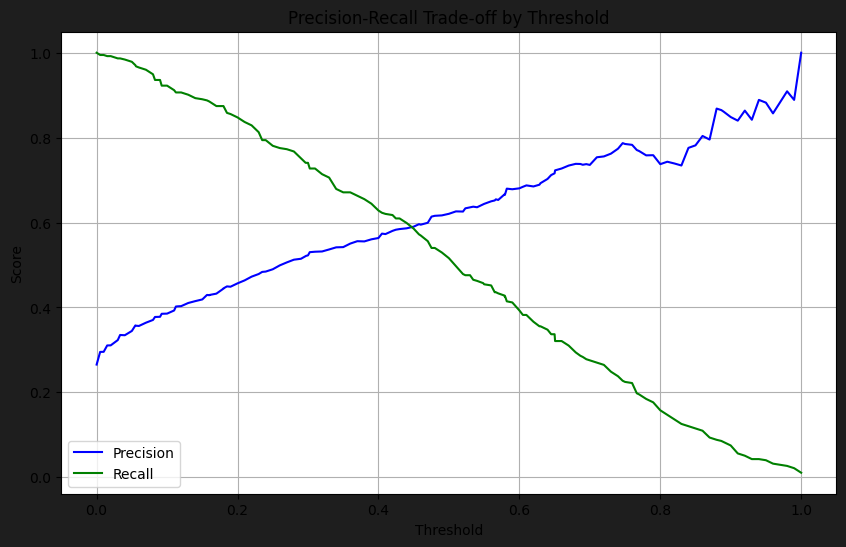

In [27]:
# Task 4: Machine Learning Model Training
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Split the data (Ab X aur y Task 3 se aa rahe hain)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

# Train Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

## Task 5: Business Decision Threshold Modeling
Evaluate Precision-Recall trade-offs to maximize retention campaign ROI.

Optimal Threshold (Max F1-Score): 0.2800
Precision at this threshold: 0.5125
Recall at this threshold: 0.7674

--- Evaluation at Optimal Threshold ---
Confusion Matrix:
[[762 273]
 [ 87 287]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.51      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409




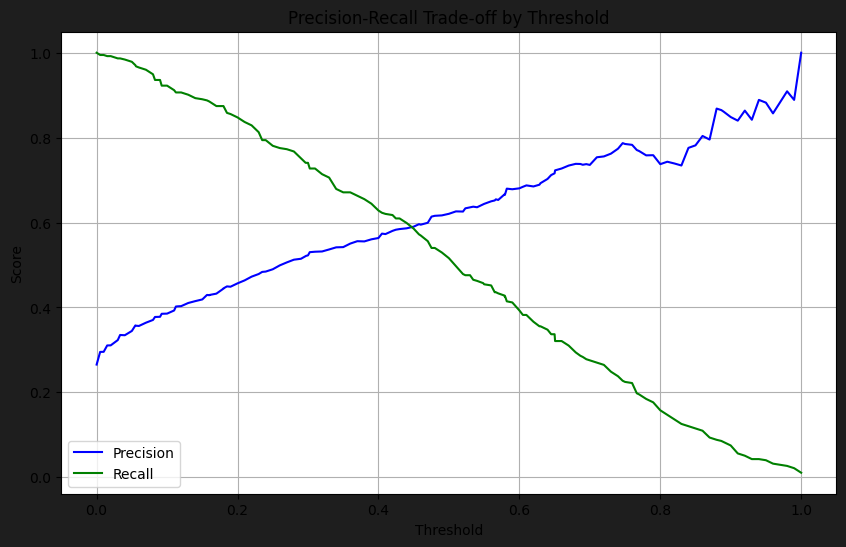

In [28]:
# Task 5: Business Decision Threshold Modeling
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report

# 1. Get probability scores (instead of just 0/1 predictions)
y_probs = model.predict_proba(X_test)[:, 1]

# 2. Calculate precision and recall for different thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# 3. Plot Precision-Recall trade-off
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall', color='green')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off by Threshold')
plt.legend()
plt.grid(True)
plt.show()

# 4. Find the optimal threshold (using F1-score)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (Max F1-Score): {optimal_threshold:.4f}")
print(f"Precision at this threshold: {precision[optimal_idx]:.4f}")
print(f"Recall at this threshold: {recall[optimal_idx]:.4f}")

# 5. Evaluate model at this optimal threshold
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)

print("\n--- Evaluation at Optimal Threshold ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimal))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimal))